https://www.kaggle.com/code/yashhvyass/adult-census-income-logistic-reg-explained-86-2

In [71]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# 0. CONTEXTO Y CARGA DE DATOS

- Objetivo de estudio:

Predecir si una persona ganará más o menos de 50000 USD al año según sus datos demográficos y socioeconómicos de una persona adulta.

- Variables de estudio: 
    - age: la edad de un individuo
    - workclass: un término general para representar el estado laboral de un individuo
    - fnlwgt: peso final. Este es el número de personas que el censo cree que la entrada representa.
    - education: el nivel más alto de educación alcanzado por un individuo
    - education_num: el nivel más alto de educación alcanzado en forma numérica
    - marital_status: estado civil de un individuo
    - occupation: el tipo general de ocupación de un individuo
    - relationship: representa qué es este individuo en relación con otros
    - race: descripciones de la raza de un individuo
    - sex: el sexo del individuo
    - capital_gain: ganancias de capital de un individuo
    - capital_loss: pérdidas de capital de un individuo
    - hours_per_week: las horas que un individuo ha reportado trabajar por semana
    - native_country: país de origen de un individuo

In [2]:
df=pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [10]:
#Procesamiento yi
df['income'].value_counts(normalize=True).round(5)

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

Estamos ante un problema de **clasificación** el cual vamos a resolver con técnicas de machine learning **supervisado**.

In [37]:
#Procesamiento xi numericas
for var in df.select_dtypes(exclude="object"):
    print(f"Variable '{var}'")
    print(df[var].mean())
    print('-'*25)

Variable 'age'
38.585548759873376
-------------------------
Variable 'fnlwgt'
189780.84851092604
-------------------------
Variable 'education.num'
10.081814549589698
-------------------------
Variable 'capital.gain'
1078.4437409718166
-------------------------
Variable 'capital.loss'
87.36822694163568
-------------------------
Variable 'hours.per.week'
40.44032947106371
-------------------------


In [39]:
#Procesamiento xi categoricas
for var in df.select_dtypes(include="object").drop(columns="income"):
    print(f"Variable '{var}'")
    print(df[var].unique())
    print('-'*30)

Variable 'workclass'
['?' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']
------------------------------
Variable 'education'
['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool']
------------------------------
Variable 'marital.status'
['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']
------------------------------
Variable 'occupation'
['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving'
 'Handlers-cleaners' 'Sales' 'Farming-fishing' 'Tech-support'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
------------------------------
Variable 'relationship'
['Not-in-family' 'Unmarried' 'Own-child' 'Other-relative' 'Husband' 'Wife']
------------------------------
Variable

# **1. ANÁLISIS DE DATOS DESCRIPTIVO** (ADD)

## 1.1. Limpieza de datos

### 1.1.1.) Valores unicos y duplicados

In [22]:
#Valores unicos
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


In [27]:
#Valores duplicados por filas
fil_dup=df.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

Hay 24 filas duplicadas


In [34]:
#Mostramos un df con todas las filas duplicadas
todas=df.duplicated(keep=False)
df.iloc[todas[todas==True].index].sort_values(by="fnlwgt").T

,29334,26531,11121,23276,23827,10357,6227,8645,19622,20507,...,9067,28796,11777,27133,7978,8453,19832,23720,18906,32419
age,39,39,49,49,49,49,90,90,19,19,...,27,27,28,28,25,25,44,44,35,35
workclass,Private,Private,Private,Private,Self-emp-not-inc,Self-emp-not-inc,Private,Private,Private,Private,...,Private,Private,Private,Private,Private,Private,Private,Private,Private,Private
fnlwgt,30916,30916,31267,31267,43479,43479,52386,52386,97261,97261,...,255582,255582,274679,274679,308144,308144,367749,367749,379959,379959
education,HS-grad,HS-grad,7th-8th,7th-8th,Some-college,Some-college,Some-college,Some-college,HS-grad,HS-grad,...,HS-grad,HS-grad,Masters,Masters,Bachelors,Bachelors,Bachelors,Bachelors,HS-grad,HS-grad
education.num,9,9,4,4,10,10,10,10,9,9,...,9,9,14,14,13,13,13,13,9,9
marital.status,Married-civ-spouse,Married-civ-spouse,Married-civ-spouse,Married-civ-spouse,Married-civ-spouse,Married-civ-spouse,Never-married,Never-married,Never-married,Never-married,...,Never-married,Never-married,Never-married,Never-married,Never-married,Never-married,Never-married,Never-married,Divorced,Divorced
occupation,Craft-repair,Craft-repair,Craft-repair,Craft-repair,Craft-repair,Craft-repair,Other-service,Other-service,Farming-fishing,Farming-fishing,...,Machine-op-inspct,Machine-op-inspct,Prof-specialty,Prof-specialty,Craft-repair,Craft-repair,Prof-specialty,Prof-specialty,Other-service,Other-service
relationship,Husband,Husband,Husband,Husband,Husband,Husband,Not-in-family,Not-in-family,Not-in-family,Not-in-family,...,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family
race,White,White,White,White,White,White,Asian-Pac-Islander,Asian-Pac-Islander,White,White,...,White,White,White,White,White,White,White,White,White,White
sex,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,...,Female,Female,Male,Male,Male,Male,Female,Female,Female,Female


In [ ]:
#Eliminamos las filas duplicadas
df.drop_duplicates(keep="last", inplace=True)
## Verificamos que se han eliminado correctamente
fil_dup=df.duplicated(keep="last") #Fila duplicada ultima aparicion
print("Ya no hay filas duplicadas" if fil_dup.sum()==0 else f"Todavía hay {fil_dup.sum()} filas duplicadas")

No hay filas duplicadas


In [36]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
col_dup=df.T.duplicated(keep="last")
print("No hay variables exactamente iguales" if col_dup.sum()==0 else f"Hay {fil_dup.sum()} variables exactamente iguales")

No hay variables exactamente iguales


### 1.1.2. Valores faltantes (NaN)

#### A) Datos enmascarados

In [42]:
#Procesamiento xi numericas
df.select_dtypes(exclude="object").describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Podemos observar como de la variable numérica `capital.gain` presenta riesgo de valores faltantes enmascarados porque la gran mayoria de sus observaciones son nulas y su máximo dista mucho del resto de la distribución. Además, `hours.per.week` deberá ser analizada por la presencia de observaciones con valores excesivamente altos.

In [51]:
df[df['capital.gain']>=df['capital.gain'].max()].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,159.000000,159.000000,159.000000,159.0,159.0,159.000000
mean,46.358491,192968.886792,12.918239,99999.0,0.0,49.798742
std,10.899009,101598.198627,2.477669,0.0,0.0,12.450804
min,21.000000,25468.000000,5.000000,99999.0,0.0,20.000000
25%,39.000000,120529.000000,10.500000,99999.0,0.0,40.000000
50%,47.000000,175642.000000,13.000000,99999.0,0.0,50.000000
75%,52.000000,236533.500000,15.000000,99999.0,0.0,60.000000
max,78.000000,553405.000000,16.000000,99999.0,0.0,80.000000


Parece que estos valores son al azar pues no observamos ningun patrón oculto en los datos, auqnue este caso será estudiado en detenimiendo en la fase de ingeniería de características.

In [59]:
df[df['hours.per.week']>=df['hours.per.week'].max()].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.0
mean,43.517647,161462.129412,10.611765,799.529412,125.717647,99.0
std,13.339533,103387.089190,3.415978,2932.860012,508.916838,0.0
min,19.000000,24790.000000,4.000000,0.000000,0.000000,99.0
25%,34.000000,89681.000000,9.000000,0.000000,0.000000,99.0
50%,42.000000,158712.000000,10.000000,0.000000,0.000000,99.0
75%,51.000000,208826.000000,13.000000,0.000000,0.000000,99.0
max,90.000000,511289.000000,16.000000,15024.000000,2415.000000,99.0


Parece que estos valores son al azar pues no observamos ningun patrón oculto en los datos, por lo que procedemos a imputarlos como valores faltantes.

In [63]:
#Vericamos reemplazo
df['hours.per.week'].replace({float(99.0): np.nan}, inplace=True)
print(f'Numero de valores faltantes enmascarados: {df['hours.per.week'].isna().sum()} observaciones')

Numero de valores faltantes enmascarados: 85 observaciones


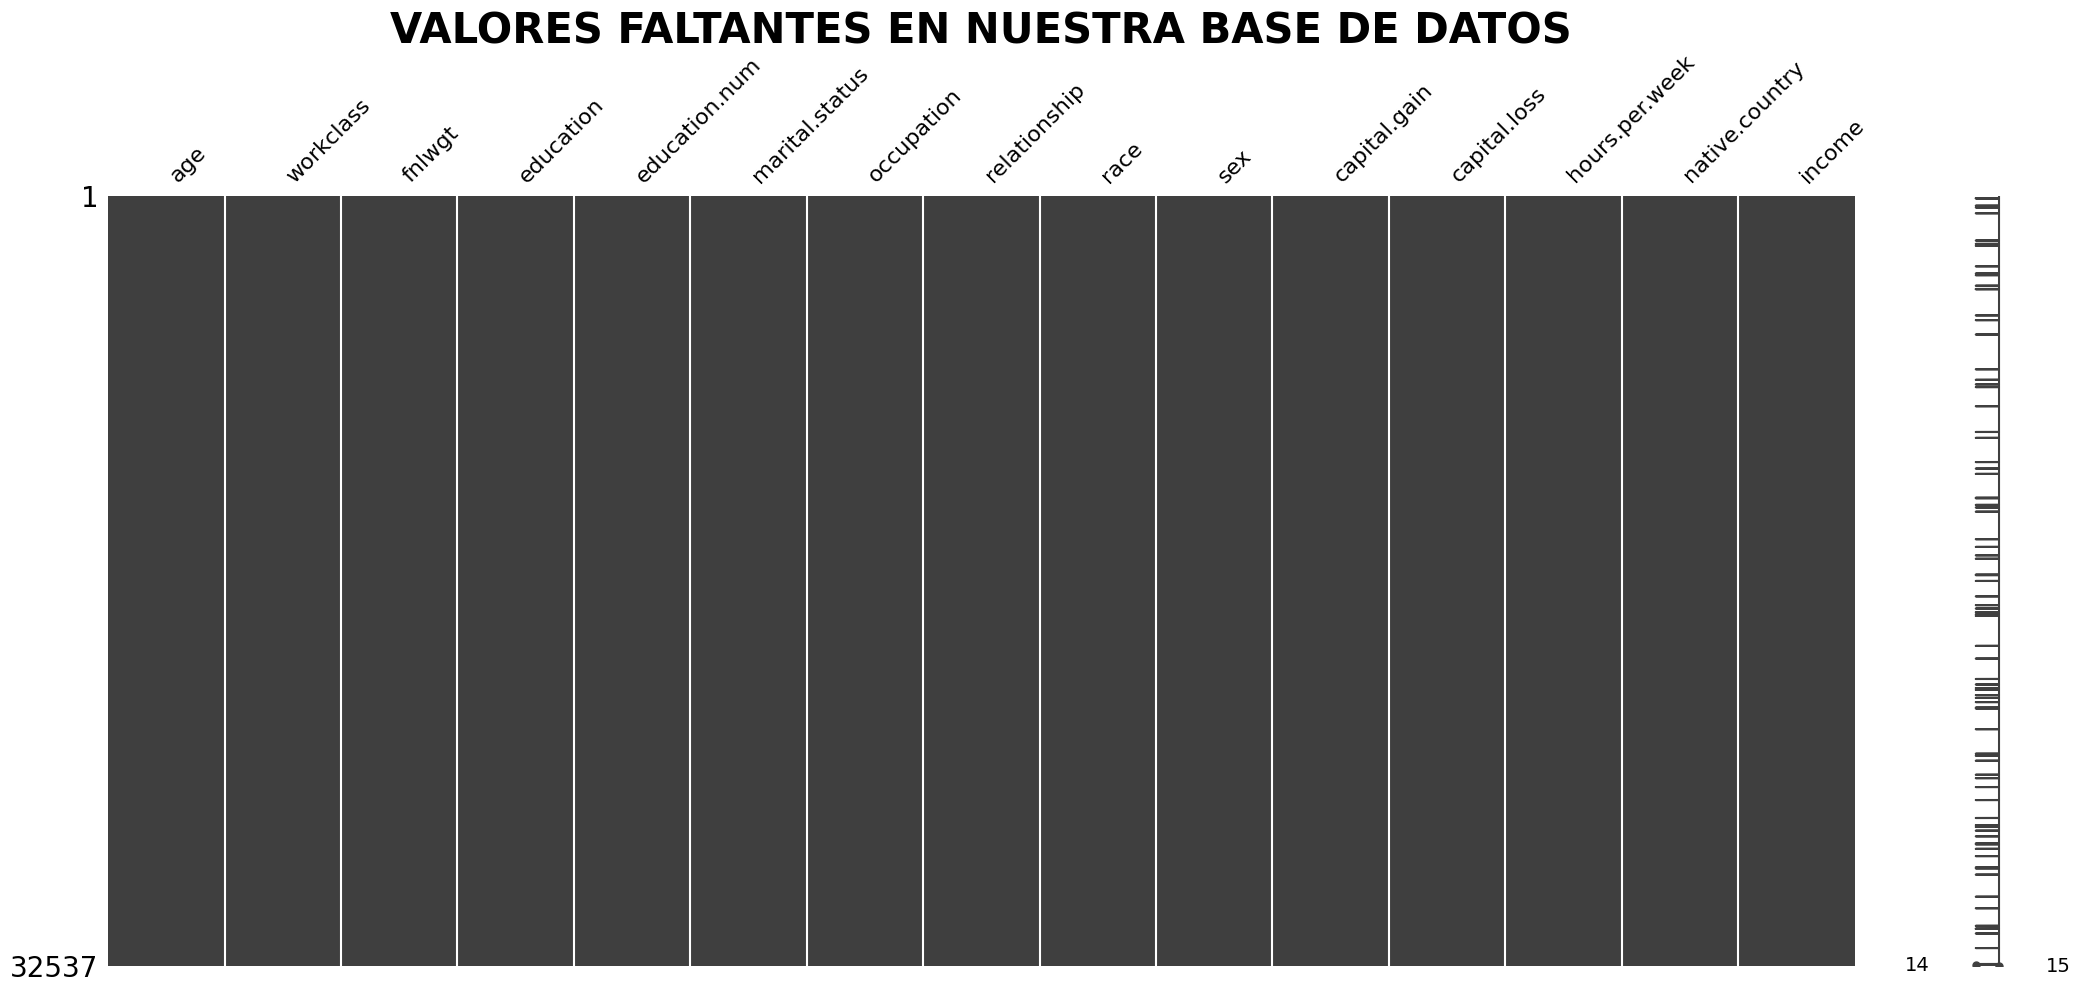

In [70]:
#Visualización final
msno.matrix(df)
plt.title("Valores faltantes en nuestra base de datos".upper(), fontweight="bold", fontsize=30)
plt.show()

## 1.2. Análisis univariante

### A) Variables Numéricas

In [74]:
for var in df.select_dtypes(exclude="object"):
    plt.subplot(2)
    sns.histplot(df[var], ax=0)
    sns.boxplot(df[var], ax=1)

plt.plot()

ValueError: Single argument to subplot must be a three-digit integer, not 2

<Figure size 640x480 with 0 Axes>

### B) Variables Categóricas

### C) Target